#SISTEMARE DATI XOR.... non impara bene la rete

qui con keras

In [18]:
# Importiamo le librerie necessarie
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense

## Creazione del dataset XOR

Definiamo gli input e gli output della funzione XOR.

In [17]:
# Dataset XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

## Creazione del modello

Creiamo una rete feedforward con:
- Un **hidden layer** con 2 neuroni e attivazione **RELU**
- Un **output layer** con 1 neurone e attivazione **sigmoidale**

In [32]:
# Definizione della rete
model = Sequential()
model.add(Input(shape=(2,)))
# provare qui con 2 neuroni o con 4
model.add(Dense(2, activation='relu')) # oppure tanh
model.add(Dense(1, activation='sigmoid'))

# Compilazione del modello
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Mostriamo un riepilogo del modello
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

## Addestramento della rete

Addestriamo la rete per 1000 epoche sul piccolo dataset XOR.

In [33]:
history  = model.fit(X, y, epochs=1000, verbose=0)

## Verifica dei risultati

Facciamo una predizione sui 4 input del XOR e confrontiamo con gli output attesi.## Verifica dei risultati

Facciamo una predizione sui 4 input del XOR e confrontiamo con gli output attesi.

Accuracy finale sul training set: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Predizioni:
Input: [0 0] → Output Predetto: 0.0 → Target: 0
Input: [0 1] → Output Predetto: 0.0 → Target: 1
Input: [1 0] → Output Predetto: 1.0 → Target: 1
Input: [1 1] → Output Predetto: 1.0 → Target: 0


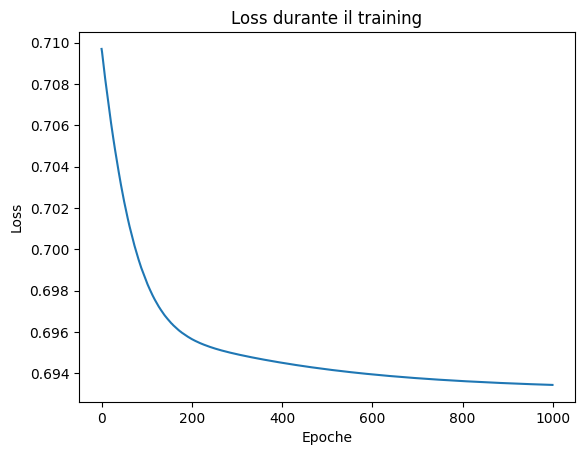

In [39]:
# Valutazione finale
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Accuracy finale sul training set: {accuracy*100:.2f}%")
# Predizione
predictions = model.predict(X)

print("\nPredizioni:")
for i in range(len(X)):
    print(f"Input: {X[i]} → Output Predetto: {predictions[i][0].round()} → Target: {y[i][0]}")

# Output dei risultati
# print("Input:")
# print(X)

# print("\nOutput previsto dalla rete (arrotondato):")
# print(predictions.round())

# print("\nOutput reale della rete (valori grezzi):")
# print(predictions)

# Grafico della loss durante il training
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.title('Loss durante il training')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.show()